In [28]:
import pandas as pd
import sqlite3
import joblib
import os
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    mean_squared_error, mean_absolute_error
)

def train_burglary_classifier_with_6plus_regression(db_path='crime_data.db', model_path='models/'):
    os.makedirs(model_path, exist_ok=True)

    # Load data
    conn = sqlite3.connect(db_path)
    crime_df = pd.read_sql_query(""" 
        SELECT crimeID, Month, Longitude, Latitude, Outcome, LSOA_code, WD24CD, Type
        FROM crime
        WHERE substr(Month, 1, 7) BETWEEN '2022-01' AND '2025-02';
    """, conn)
    prices_df = pd.read_sql_query("SELECT WD23CD, Average_Price FROM ward_average_prices;", conn)
    conn.close()

    crime_df['Month'] = pd.to_datetime(crime_df['Month'], format='%Y-%m')

    all_combinations = []
    for target_month in pd.date_range('2024-01', '2025-02', freq='MS'):
        month1 = target_month - pd.DateOffset(years=2)
        month2 = target_month - pd.DateOffset(years=1)
        retrospective_months = [target_month - pd.DateOffset(months=i) for i in [1, 2, 3]]

        month1_data = crime_df[crime_df['Month'] == month1]
        month2_data = crime_df[crime_df['Month'] == month2]
        retrospective_data = crime_df[crime_df['Month'].isin(retrospective_months)]

        def agg(df, name):
            return df.groupby('LSOA_code').size().reset_index(name=name)

        total1 = agg(month1_data, 'crimes_m1')
        total2 = agg(month2_data, 'crimes_m2')
        burg1 = agg(month1_data[month1_data['Type'] == 'Burglary'], 'burg_m1')
        burg2 = agg(month2_data[month2_data['Type'] == 'Burglary'], 'burg_m2')

        total_3m = retrospective_data.groupby('LSOA_code').size().reset_index(name='crime_3m_sum')
        burg_3m = retrospective_data[retrospective_data['Type'] == 'Burglary'] \
            .groupby('LSOA_code').size().reset_index(name='burglary_3m_sum')

        total_3m['crime_3m_avg'] = total_3m['crime_3m_sum'] / 3
        burg_3m['burglary_3m_avg'] = burg_3m['burglary_3m_sum'] / 3

        features_df = total1.merge(total2, on='LSOA_code', how='outer') \
                            .merge(burg1, on='LSOA_code', how='outer') \
                            .merge(burg2, on='LSOA_code', how='outer') \
                            .merge(total_3m[['LSOA_code', 'crime_3m_avg']], on='LSOA_code', how='outer') \
                            .merge(burg_3m[['LSOA_code', 'burglary_3m_avg']], on='LSOA_code', how='outer') \
                            .fillna(0)

        features_df['trend'] = features_df['crimes_m2'] - features_df['crimes_m1']
        features_df['ma'] = features_df[['crimes_m1', 'crimes_m2']].mean(axis=1)

        # Price mapping
        lsoa_to_ward = month1_data[['LSOA_code', 'WD24CD']].drop_duplicates()
        lsoa_price_map = lsoa_to_ward.merge(prices_df, left_on='WD24CD', right_on='WD23CD', how='left')
        features_df = features_df.merge(lsoa_price_map[['LSOA_code', 'Average_Price']], on='LSOA_code', how='left')
        features_df = features_df.dropna(subset=['Average_Price'])

        # Target
        target_data = crime_df[(crime_df['Month'] == target_month) & (crime_df['Type'] == 'Burglary')]
        target_counts = target_data.groupby('LSOA_code').size().reset_index(name='target')
        features_df = features_df.merge(target_counts, on='LSOA_code', how='left').fillna({'target': 0})

        all_combinations.append(features_df)

    combined_data = pd.concat(all_combinations, ignore_index=True)

    # Define target class: 0-5, and 6+ as 6
    combined_data['target_class'] = combined_data['target'].apply(lambda x: x if x < 6 else 6)

    feature_cols = [
        'crimes_m1', 'crimes_m2', 'burg_m1', 'burg_m2',
        'trend', 'ma', 'crime_3m_avg', 'burglary_3m_avg',
        'Average_Price'
    ]
    X = combined_data[feature_cols]
    y_class = combined_data['target_class']
    y_reg = combined_data['target']

    # Stratified split
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    for train_idx, test_idx in sss.split(X, y_class):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train_class, y_test_class = y_class.iloc[train_idx], y_class.iloc[test_idx]
        y_train_reg, y_test_reg = y_reg.iloc[train_idx], y_reg.iloc[test_idx]

    # Train classifier
    clf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
    clf.fit(X_train, y_train_class)
    y_pred_class = clf.predict(X_test)

    print("\n--- Classification Report (0–6) ---")
    print(classification_report(y_test_class, y_pred_class))
    print("Confusion Matrix:\n", confusion_matrix(y_test_class, y_pred_class))

    # Train regressor on 6+ class
    reg_train_idx = y_train_class[y_train_class == 6].index
    reg = RandomForestRegressor(n_estimators=200, random_state=42)
    reg.fit(X_train.loc[reg_train_idx], y_train_reg.loc[reg_train_idx])

    # Apply regressor to test instances where classifier predicted class 6
    reg_test_idx = y_test_class.index[y_pred_class == 6]
    reg_y_pred = reg.predict(X_test.loc[reg_test_idx])
    reg_y_pred_rounded = np.round(reg_y_pred).astype(int)

    # Combine final predictions
    final_pred = pd.Series(y_pred_class, index=y_test_class.index)
    final_pred.loc[reg_test_idx] = reg_y_pred_rounded
    final_true = y_test_reg

    # Final evaluation
    exact_match_acc = (final_pred == final_true).mean()
    print(f"\n--- Final Combined Accuracy (classification + regression) ---")
    print(f"Exact match accuracy: {exact_match_acc * 100:.2f}%")

    if len(reg_y_pred_rounded) > 0:
        print("\n--- Regression Performance on 6+ ---")
        print("RMSE:", np.sqrt(mean_squared_error(y_test_reg.loc[reg_test_idx], reg_y_pred_rounded)))
        print("MAE:", mean_absolute_error(y_test_reg.loc[reg_test_idx], reg_y_pred_rounded))

    # Save models and features
    joblib.dump(clf, os.path.join(model_path, 'hybrid_classifier.pkl'))
    joblib.dump(reg, os.path.join(model_path, 'six_plus_regressor.pkl'))
    joblib.dump(feature_cols, os.path.join(model_path, 'feature_columns.pkl'))
    print("\nModels and features saved to:", model_path)


train_burglary_classifier_with_6plus_regression()



--- Classification Report (0–6) ---
              precision    recall  f1-score   support

         0.0       0.65      0.90      0.75      7334
         1.0       0.54      0.35      0.42      3709
         2.0       0.62      0.29      0.40      1613
         3.0       0.74      0.33      0.46       724
         4.0       0.84      0.37      0.52       303
         5.0       0.83      0.45      0.59       143
         6.0       0.78      0.59      0.68       175

    accuracy                           0.64     14001
   macro avg       0.71      0.47      0.55     14001
weighted avg       0.63      0.64      0.60     14001

Confusion Matrix:
 [[6605  614   89   18    6    2    0]
 [2279 1290  107   22    3    3    5]
 [ 849  261  473   15    4    3    8]
 [ 292  132   42  242    5    3    8]
 [  96   53   23   11  113    1    6]
 [  41   19    8    8    0   65    2]
 [  16   22   17   11    4    1  104]]

--- Final Combined Accuracy (classification + regression) ---
Exact match accur

In [55]:
def predict_burglary_for_month(target_month, db_path='crime_data.db', model_path='models/'):
    import pandas as pd
    import sqlite3
    import joblib
    import numpy as np
    import os
    from dateutil.relativedelta import relativedelta

    # Load models
    clf = joblib.load(os.path.join(model_path, 'hybrid_classifier.pkl'))
    reg = joblib.load(os.path.join(model_path, 'six_plus_regressor.pkl'))
    feature_cols = joblib.load(os.path.join(model_path, 'feature_columns.pkl'))

    # Parse target month
    target_month = pd.to_datetime(target_month)

    # Load real data
    conn = sqlite3.connect(db_path)
    crime_df = pd.read_sql_query("""
        SELECT crimeID, Month, Longitude, Latitude, Outcome, LSOA_code, WD24CD, Type
        FROM crime
        WHERE substr(Month, 1, 7) BETWEEN '2022-01' AND '2025-02';
    """, conn)
    prices_df = pd.read_sql_query("SELECT WD23CD, Average_Price FROM ward_average_prices;", conn)
    conn.close()
    crime_df['Month'] = pd.to_datetime(crime_df['Month'], format='%Y-%m')
    predicted_df = crime_df.copy()

    # If target_month > 2025-02, simulate predictions recursively
    current_month = pd.to_datetime("2025-03")
    while current_month < target_month:
        pred = predict_burglary_for_month(current_month.strftime('%Y-%m'), db_path, model_path)
        synthetic_rows = []
        for _, row in pred.iterrows():
            for i in range(int(row['predicted_burglaries'])):
                synthetic_rows.append({
                    'crimeID': f'synth_{row["LSOA_code"]}_{i}_{current_month.strftime("%Y%m")}',
                    'Month': pd.to_datetime(row['Month']),
                    'Longitude': np.nan,
                    'Latitude': np.nan,
                    'Outcome': None,
                    'LSOA_code': row['LSOA_code'],
                    'WD24CD': row.get('WD24CD', None),
                    'Type': 'Burglary'
                })
        predicted_df = pd.concat([predicted_df, pd.DataFrame(synthetic_rows)], ignore_index=True)
        current_month += relativedelta(months=1)

    # Compute reference months
    m1 = target_month - relativedelta(years=2)
    m2 = target_month - relativedelta(years=1)
    retrospective_months = [target_month - relativedelta(months=i) for i in [1, 2, 3]]

    def agg(df, name):
        return df.groupby('LSOA_code').size().reset_index(name=name)

    m1_data = predicted_df[predicted_df['Month'] == m1]
    m2_data = predicted_df[predicted_df['Month'] == m2]
    retro_data = predicted_df[predicted_df['Month'].isin(retrospective_months)]

    total1 = agg(m1_data, 'crimes_m1')
    total2 = agg(m2_data, 'crimes_m2')
    burg1 = agg(m1_data[m1_data['Type'] == 'Burglary'], 'burg_m1')
    burg2 = agg(m2_data[m2_data['Type'] == 'Burglary'], 'burg_m2')

    total_3m = retro_data.groupby('LSOA_code').size().reset_index(name='crime_3m_sum')
    burg_3m = retro_data[retro_data['Type'] == 'Burglary'].groupby('LSOA_code').size().reset_index(name='burglary_3m_sum')
    total_3m['crime_3m_avg'] = total_3m['crime_3m_sum'] / 3
    burg_3m['burglary_3m_avg'] = burg_3m['burglary_3m_sum'] / 3

    features_df = total1.merge(total2, on='LSOA_code', how='outer') \
                        .merge(burg1, on='LSOA_code', how='outer') \
                        .merge(burg2, on='LSOA_code', how='outer') \
                        .merge(total_3m[['LSOA_code', 'crime_3m_avg']], on='LSOA_code', how='outer') \
                        .merge(burg_3m[['LSOA_code', 'burglary_3m_avg']], on='LSOA_code', how='outer') \
                        .fillna(0)

    features_df['trend'] = features_df['crimes_m2'] - features_df['crimes_m1']
    features_df['ma'] = features_df[['crimes_m1', 'crimes_m2']].mean(axis=1)

    # Add WD24CD and price
    ward_map = m1_data[['LSOA_code', 'WD24CD']].drop_duplicates()
    price_map = ward_map.merge(prices_df, left_on='WD24CD', right_on='WD23CD', how='left')
    features_df = features_df.merge(ward_map, on='LSOA_code', how='left')
    features_df = features_df.merge(price_map[['LSOA_code', 'Average_Price']], on='LSOA_code', how='left')

    # Remove LSOAs without WD24CD
    features_df = features_df.dropna(subset=['WD24CD'])

    # Fill missing prices with mean
    mean_price = features_df['Average_Price'].mean()
    features_df['Average_Price'] = features_df['Average_Price'].fillna(mean_price)

    # Predict
    X = features_df[feature_cols]
    class_pred = clf.predict(X)
    final_pred = pd.Series(class_pred, index=features_df.index)

    reg_indices = features_df.index[final_pred == 6]
    if len(reg_indices) > 0:
        reg_pred = reg.predict(X.loc[reg_indices])
        final_pred.loc[reg_indices] = np.round(reg_pred).astype(int)

    result_df = features_df[['LSOA_code', 'WD24CD']].copy()
    result_df['predicted_burglaries'] = final_pred.values.astype(int)
    result_df['Month'] = target_month.strftime('%Y-%m')

    return result_df



predicted_burglary = predict_burglary_for_month(target_month = "2025-03")
predicted_burglary.head()

,LSOA_code,WD24CD,predicted_burglaries,Month
0,E01000001,E05009288,0,2025-03
1,E01000002,E05009302,0,2025-03
3,E01000005,E05009308,0,2025-03
4,E01000006,E05014066,0,2025-03
5,E01000007,E05014066,2,2025-03


In [56]:
import pandas as pd
import pulp


def allocate_police_hours_stepwise_reduction(
    df,
    total_hours_per_ward=800,
    patrol_block=2,
    step_percent=0.10,
    reduction_per_step=0.03,
    max_steps=5
):
    """
    ILP with stepwise burglary reduction based on incremental patrol beyond 50% equal allocation.

    Parameters:
        df (pd.DataFrame): Must contain ['LSOA_code', 'WD24CD', 'predicted_burglaries']
        total_hours_per_ward (int): Total available officer hours per ward
        patrol_block (int): Patrol unit in hours (must be divisible by 2)
        step_percent (float): Additional % of base per step (e.g., 0.10 = 10%)
        reduction_per_step (float): Crime reduction per step (e.g., 0.03 = 3%)
        max_steps (int): Maximum number of steps allowed (e.g., 5 = 30% max reduction)

    Returns:
        pd.DataFrame: Allocation results per LSOA
    """

    df = df.groupby(['LSOA_code', 'WD24CD'], as_index=False)['predicted_burglaries'].mean()
    results = []

    for ward in df['WD24CD'].unique():
        ward_df = df[df['WD24CD'] == ward]
        lsoas = ward_df['LSOA_code'].tolist()
        base_crime = dict(zip(lsoas, ward_df['predicted_burglaries']))
        n_lsoas = len(lsoas)

        # 50% baseline equally distributed
        baseline_hours = (0.5 * total_hours_per_ward) / n_lsoas
        baseline_hours = round(baseline_hours / patrol_block) * patrol_block

        # Step size in hours (e.g., 10% of baseline)
        step_size = baseline_hours * step_percent

        # Total additional budget (50% reinforcement)
        additional_budget = total_hours_per_ward - (baseline_hours * n_lsoas)

        # ILP model
        prob = pulp.LpProblem(f"ILP_Stepwise_{ward}", pulp.LpMinimize)

        # Decision vars: how many steps per LSOA (0–max_steps)
        x = {
            lsoa: pulp.LpVariable(f"x_{lsoa}", lowBound=0, upBound=max_steps, cat='Integer')
            for lsoa in lsoas
        }

        # Objective: minimize total adjusted crime using stepwise penalty
        prob += pulp.lpSum([
            base_crime[lsoa] * (1 - reduction_per_step * x[lsoa])
            for lsoa in lsoas
        ])

        # Constraint: total additional hours used ≤ reinforcement budget
        prob += pulp.lpSum([
            step_size * x[lsoa] for lsoa in lsoas
        ]) <= additional_budget

        # Solve
        prob.solve(pulp.PULP_CBC_CMD(msg=0))

        for lsoa in lsoas:
            steps = x[lsoa].varValue
            additional_hours = step_size * steps
            total_hours = baseline_hours + additional_hours
            adjusted = base_crime[lsoa] * (1 - reduction_per_step * steps)
            results.append({
                'WD24CD': ward,
                'LSOA_code': lsoa,
                'baseline_hours': baseline_hours,
                'reinforcement_hours': additional_hours,
                'allocated_hours': total_hours,
                'original_predicted_burglaries': base_crime[lsoa],
                'adjusted_predicted_burglaries': adjusted
            })

    return pd.DataFrame(results)



allocate_police_hours_stepwise_reduction(predicted_burglary)

,WD24CD,LSOA_code,baseline_hours,reinforcement_hours,allocated_hours,original_predicted_burglaries,adjusted_predicted_burglaries
0,E05009288,E01000001,400,0.0,400.0,0.0,0.0
1,E05009302,E01000002,400,0.0,400.0,0.0,0.0
2,E05009308,E01000005,400,0.0,400.0,0.0,0.0
3,E05014066,E01000006,66,0.0,66.0,0.0,0.0
4,E05014066,E01000007,66,33.0,99.0,2.0,1.7
...,...,...,...,...,...,...,...
5196,E05012085,E01035458,400,0.0,400.0,0.0,0.0
5197,W05001383,W01001076,400,0.0,400.0,0.0,0.0
5198,W05001625,W01001320,400,0.0,400.0,0.0,0.0
5199,W05001289,W01001836,400,0.0,400.0,0.0,0.0


In [57]:
import pandas as pd
import sqlite3
import joblib
import numpy as np
import os
from dateutil.relativedelta import relativedelta

def predict_burglary_recursive_mar2025_to_feb2026(db_path='crime_data.db', model_path='models/'):
    # Load models
    clf = joblib.load(os.path.join(model_path, 'hybrid_classifier.pkl'))
    reg = joblib.load(os.path.join(model_path, 'six_plus_regressor.pkl'))
    feature_cols = joblib.load(os.path.join(model_path, 'feature_columns.pkl'))

    # Load real data up to Feb 2025
    conn = sqlite3.connect(db_path)
    crime_df = pd.read_sql_query("""
        SELECT crimeID, Month, Longitude, Latitude, Outcome, LSOA_code, WD24CD, Type
        FROM crime
        WHERE substr(Month, 1, 7) BETWEEN '2022-01' AND '2025-02';
    """, conn)
    prices_df = pd.read_sql_query("SELECT WD23CD, Average_Price FROM ward_average_prices;", conn)
    conn.close()

    crime_df['Month'] = pd.to_datetime(crime_df['Month'], format='%Y-%m')
    predicted_df = crime_df.copy()

    future_months = pd.date_range('2025-03', '2026-02', freq='MS')
    all_predictions = []

    for target_month in future_months:
        m1 = target_month - relativedelta(years=2)
        m2 = target_month - relativedelta(years=1)
        retrospective_months = [target_month - relativedelta(months=i) for i in [1, 2, 3]]

        def agg(df, name):
            return df.groupby('LSOA_code').size().reset_index(name=name)

        m1_data = predicted_df[predicted_df['Month'] == m1]
        m2_data = predicted_df[predicted_df['Month'] == m2]
        retro_data = predicted_df[predicted_df['Month'].isin(retrospective_months)]

        total1 = agg(m1_data, 'crimes_m1')
        total2 = agg(m2_data, 'crimes_m2')
        burg1 = agg(m1_data[m1_data['Type'] == 'Burglary'], 'burg_m1')
        burg2 = agg(m2_data[m2_data['Type'] == 'Burglary'], 'burg_m2')

        total_3m = retro_data.groupby('LSOA_code').size().reset_index(name='crime_3m_sum')
        burg_3m = retro_data[retro_data['Type'] == 'Burglary'].groupby('LSOA_code').size().reset_index(name='burglary_3m_sum')
        total_3m['crime_3m_avg'] = total_3m['crime_3m_sum'] / 3
        burg_3m['burglary_3m_avg'] = burg_3m['burglary_3m_sum'] / 3

        features_df = total1.merge(total2, on='LSOA_code', how='outer') \
                            .merge(burg1, on='LSOA_code', how='outer') \
                            .merge(burg2, on='LSOA_code', how='outer') \
                            .merge(total_3m[['LSOA_code', 'crime_3m_avg']], on='LSOA_code', how='outer') \
                            .merge(burg_3m[['LSOA_code', 'burglary_3m_avg']], on='LSOA_code', how='outer') \
                            .fillna(0)

        features_df['trend'] = features_df['crimes_m2'] - features_df['crimes_m1']
        features_df['ma'] = features_df[['crimes_m1', 'crimes_m2']].mean(axis=1)

        # Map LSOA to price
        m1_ward_map = m1_data[['LSOA_code', 'WD24CD']].drop_duplicates()
        price_map = m1_ward_map.merge(prices_df, left_on='WD24CD', right_on='WD23CD', how='left')
        features_df = features_df.merge(price_map[['LSOA_code', 'Average_Price']], on='LSOA_code', how='left')
        features_df = features_df.dropna(subset=['Average_Price'])

        # Predict
        X = features_df[feature_cols]
        class_pred = clf.predict(X)
        final_pred = pd.Series(class_pred, index=features_df.index)

        # Apply regression to class 6+
        reg_indices = features_df.index[final_pred == 6]
        if len(reg_indices) > 0:
            reg_pred = reg.predict(X.loc[reg_indices])
            final_pred.loc[reg_indices] = np.round(reg_pred).astype(int)

        # Store prediction
        pred_df = features_df[['LSOA_code']].copy()
        pred_df['predicted_burglaries'] = final_pred.values.astype(int)
        pred_df['Month'] = target_month.strftime('%Y-%m')
        all_predictions.append(pred_df)

        # Add predicted data for recursion
        synthetic_rows = []
        for _, row in pred_df.iterrows():
            for i in range(row['predicted_burglaries']):
                synthetic_rows.append({
                    'crimeID': f'synth_{row["LSOA_code"]}_{i}_{target_month.strftime("%Y%m")}',
                    'Month': pd.to_datetime(row['Month']),
                    'Longitude': np.nan,
                    'Latitude': np.nan,
                    'Outcome': None,
                    'LSOA_code': row['LSOA_code'],
                    'WD24CD': None,
                    'Type': 'Burglary'
                })
        predicted_df = pd.concat([predicted_df, pd.DataFrame(synthetic_rows)], ignore_index=True)

    final_df = pd.concat(all_predictions, ignore_index=True)
    return final_df


In [ ]:
def evaluate_burglary_prediction_jan2025(db_path='crime_data.db', model_path='models/', output_file='jan2025_burglary_predictions.csv'):
    import pandas as pd
    import numpy as np
    import sqlite3
    import joblib
    import os
    from dateutil.relativedelta import relativedelta
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

    # Load models and features
    clf = joblib.load(os.path.join(model_path, 'hybrid_classifier.pkl'))
    reg = joblib.load(os.path.join(model_path, 'six_plus_regressor.pkl'))
    feature_cols = joblib.load(os.path.join(model_path, 'feature_columns.pkl'))

    # Time references
    target_month = pd.to_datetime('2025-01-01')
    month1 = target_month - relativedelta(years=2)
    month2 = target_month - relativedelta(years=1)
    retrospective_months = [target_month - relativedelta(months=i) for i in [1, 2, 3]]

    # Load data
    conn = sqlite3.connect(db_path)
    crime_df = pd.read_sql_query(""" 
        SELECT Month, Type, LSOA_code, WD24CD
        FROM crime
        WHERE substr(Month, 1, 7) BETWEEN '2022-01' AND '2025-02';
    """, conn)
    prices_df = pd.read_sql_query("SELECT WD23CD, Average_Price FROM ward_average_prices;", conn)
    conn.close()

    crime_df['Month'] = pd.to_datetime(crime_df['Month'])

    # Subset for relevant months
    month1_data = crime_df[crime_df['Month'] == month1]
    month2_data = crime_df[crime_df['Month'] == month2]
    retrospective_data = crime_df[crime_df['Month'].isin(retrospective_months)]

    def agg(df, name):
        return df.groupby('LSOA_code').size().reset_index(name=name)

    total1 = agg(month1_data, 'crimes_m1')
    total2 = agg(month2_data, 'crimes_m2')
    burg1 = agg(month1_data[month1_data['Type'] == 'Burglary'], 'burg_m1')
    burg2 = agg(month2_data[month2_data['Type'] == 'Burglary'], 'burg_m2')

    total_3m = retrospective_data.groupby('LSOA_code').size().reset_index(name='crime_3m_sum')
    burg_3m = retrospective_data[retrospective_data['Type'] == 'Burglary'] \
        .groupby('LSOA_code').size().reset_index(name='burglary_3m_sum')

    total_3m['crime_3m_avg'] = total_3m['crime_3m_sum'] / 3
    burg_3m['burglary_3m_avg'] = burg_3m['burglary_3m_sum'] / 3

    # Merge all features
    features_df = total1.merge(total2, on='LSOA_code', how='outer') \
        .merge(burg1, on='LSOA_code', how='outer') \
        .merge(burg2, on='LSOA_code', how='outer') \
        .merge(total_3m[['LSOA_code', 'crime_3m_avg']], on='LSOA_code', how='outer') \
        .merge(burg_3m[['LSOA_code', 'burglary_3m_avg']], on='LSOA_code', how='outer') \
        .fillna(0)

    features_df['trend'] = features_df['crimes_m2'] - features_df['crimes_m1']
    features_df['ma'] = features_df[['crimes_m1', 'crimes_m2']].mean(axis=1)

    # Add house price
    lsoa_to_ward = month1_data[['LSOA_code', 'WD24CD']].drop_duplicates()
    lsoa_price_map = lsoa_to_ward.merge(prices_df, left_on='WD24CD', right_on='WD23CD', how='left')
    features_df = features_df.merge(lsoa_price_map[['LSOA_code', 'Average_Price']], on='LSOA_code', how='left')
    features_df = features_df.dropna(subset=['Average_Price'])

    # Add actual burglary count for Jan 2025
    target_data = crime_df[(crime_df['Month'] == target_month) & (crime_df['Type'] == 'Burglary')]
    actual_counts = target_data.groupby('LSOA_code').size().reset_index(name='actual_burglaries')
    features_df = features_df.merge(actual_counts, on='LSOA_code', how='left').fillna({'actual_burglaries': 0})

    # Predict
    X = features_df[feature_cols]
    y_class_pred = clf.predict(X)
    features_df['predicted_burglaries'] = y_class_pred

    # Refine 6+ predictions using regression
    idx_6plus = features_df.index[features_df['predicted_burglaries'] == 6]
    if not idx_6plus.empty:
        refined_preds = np.round(reg.predict(X.loc[idx_6plus])).astype(int)
        features_df.loc[idx_6plus, 'predicted_burglaries'] = refined_preds

    # Evaluation
    y_true = features_df['actual_burglaries']
    y_pred = features_df['predicted_burglaries']

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print("\n--- Evaluation Metrics for January 2025 ---")
    print(f"RMSE: {rmse:.3f}")
    print(f"MAE: {mae:.3f}")
    print(f"R²:  {r2:.3f}")

    # Save to file
    features_df[['LSOA_code', 'predicted_burglaries', 'actual_burglaries']] \
        .to_csv(output_file, index=False)
    print(f"\nPredictions saved to: {output_file}")

    return features_df[['LSOA_code', 'predicted_burglaries', 'actual_burglaries']]

df_eval = evaluate_burglary_prediction_jan2025()
df_eval.head()



--- Evaluation Metrics for January 2025 ---
RMSE: 0.536
MAE: 0.123
R²:  0.861

Predictions saved to: jan2025_burglary_predictions.csv


,LSOA_code,predicted_burglaries,actual_burglaries
0,E01000001,0.0,0.0
1,E01000002,0.0,0.0
2,E01000003,1.0,1.0
3,E01000005,0.0,0.0
4,E01000006,0.0,0.0


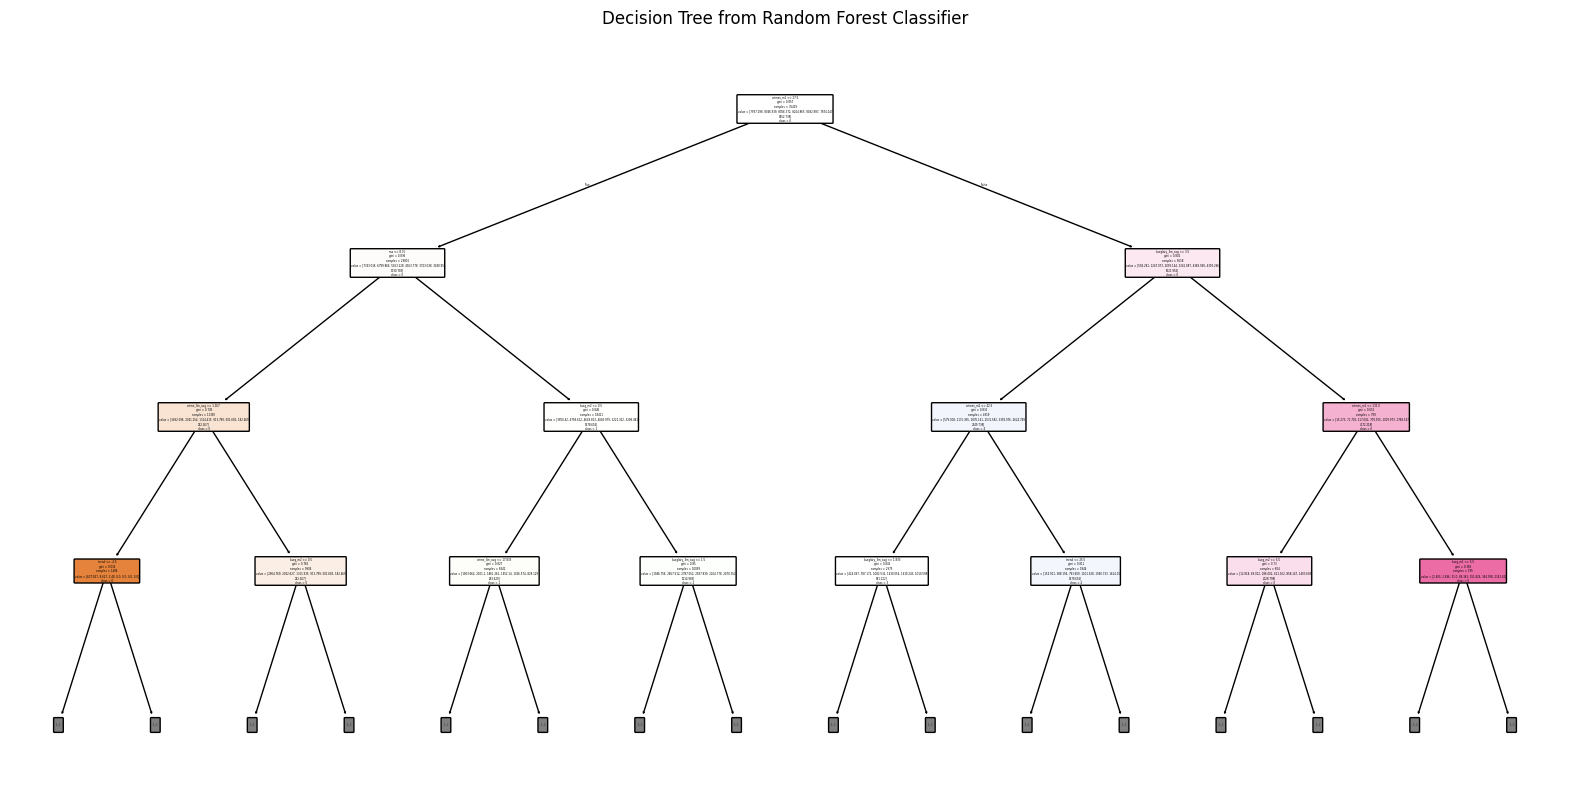

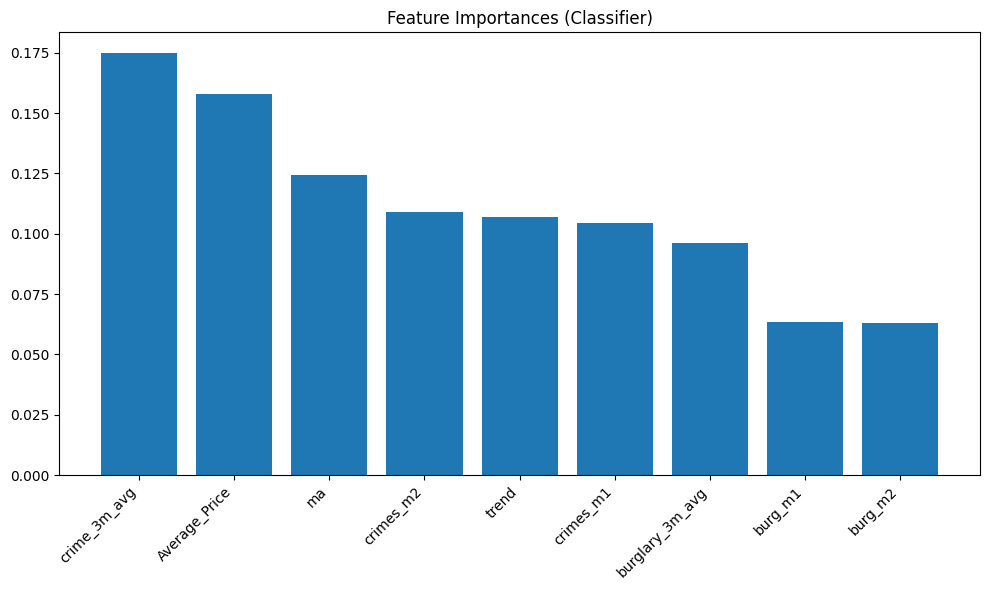

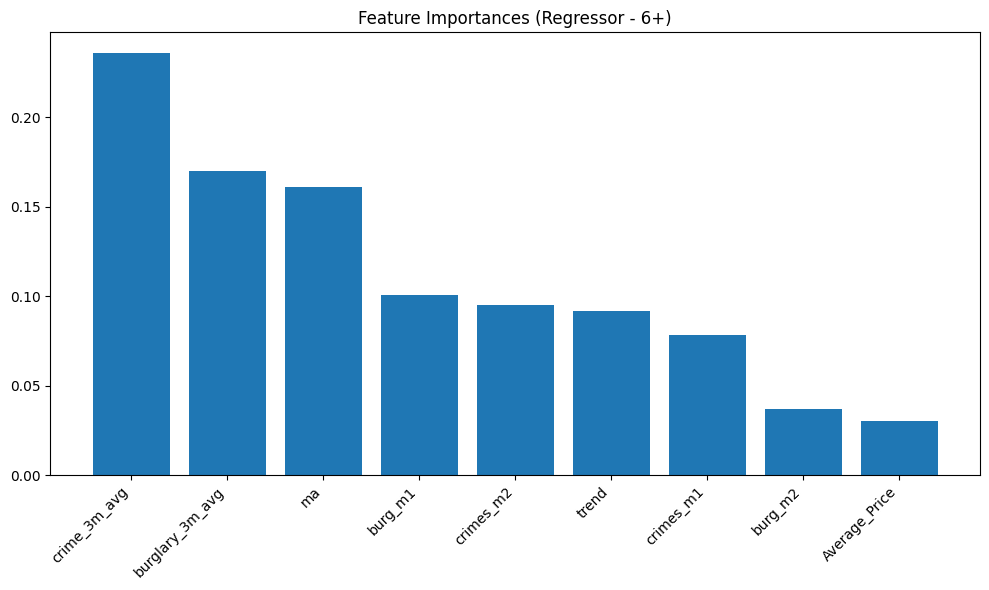

In [31]:
import joblib
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import numpy as np
import os

# === Load models and feature names from the saved model path ===
model_path = 'models/'  # or pass as argument if dynamic
clf = joblib.load(os.path.join(model_path, 'hybrid_classifier.pkl'))
reg = joblib.load(os.path.join(model_path, 'six_plus_regressor.pkl'))
feature_cols = joblib.load(os.path.join(model_path, 'feature_columns.pkl'))

# === 1. Plot one decision tree from the RandomForestClassifier ===
estimator = clf.estimators_[0]  # Use the first tree

plt.figure(figsize=(20, 10))
plot_tree(
    estimator,
    feature_names=feature_cols,
    class_names=[str(i) for i in range(7)],  # classes: 0 to 6
    filled=True,
    rounded=True,
    max_depth=3  # limit depth for readability
)
plt.title("Decision Tree from Random Forest Classifier")
plt.show()

# === 2. Feature importances from classifier ===
clf_importances = clf.feature_importances_
indices = np.argsort(clf_importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances (Classifier)")
plt.bar(range(len(feature_cols)), clf_importances[indices], align="center")
plt.xticks(range(len(feature_cols)), np.array(feature_cols)[indices], rotation=45, ha='right')
plt.tight_layout()
plt.show()

# === 3. Feature importances from regressor ===
reg_importances = reg.feature_importances_
reg_indices = np.argsort(reg_importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances (Regressor - 6+)")
plt.bar(range(len(feature_cols)), reg_importances[reg_indices], align="center")
plt.xticks(range(len(feature_cols)), np.array(feature_cols)[reg_indices], rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [30]:
reg_importances = reg.feature_importances_
reg_indices = np.argsort(reg_importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances - Regressor (6+)")
plt.bar(range(len(feature_cols)), reg_importances[reg_indices], align="center")
plt.xticks(range(len(feature_cols)), np.array(feature_cols)[reg_indices], rotation=45, ha="right")
plt.tight_layout()
plt.show()


NameError: name 'reg' is not defined

In [16]:
print(len(result))

39855


In [20]:
# Exact match count
exact_matches = (result['predicted'] == result['target_burglaries']).sum()
total_samples = len(result)

# Percentage of exact matches
exact_match_percentage = (exact_matches / total_samples) * 100

print("\n--- Regression Evaluation ---")
print(f"  Exact Matches: {exact_matches} out of {total_samples}")
print(f"  Exact Match Percentage: {exact_match_percentage:.2f}%")



--- Regression Evaluation ---
  Exact Matches: 38142 out of 39855
  Exact Match Percentage: 95.70%
